# Assignment 2 — Task 1

This notebook modifies the instructor's [original regularization notebook](https://github.com/chaklam-silpasuwanchai/Python-for-Machine-Learning/blob/main/01%20-%20Supervised/01%20-%20Regression/03%20-%20Bias-Variance%20Tradeoff%20and%20Regularization.ipynb) while keeping its main interface: the first column of `X` is the intercept, `method='mini'` selects mini-batch gradient descent, and `_coef()`/`_bias()` expose the learned parameters.

The requested additions are:

1. an R² function;
2. selectable zero or Xavier initialization;
3. optional momentum; and
4. a coefficient-based feature-importance plot.

## Step 1 — Imports and the modified class

The cell below is self-contained. Xavier initialization samples every weight from $[-1/\sqrt{m}, 1/\sqrt{m}]$, where $m$ is the number of input weights. Momentum uses the update supplied in the assignment: `theta = theta - step + momentum * prev_step`.

In [1]:
"""Task 1: enhanced version of the course's from-scratch regression class.

The public API intentionally stays close to the original notebook.  Input X is
expected to contain an intercept column of ones as its first column.
"""

from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import KFold


class NoRegularization:
    """No penalty; useful when ordinary linear regression is required."""

    def __call__(self, theta):
        return 0.0

    def derivation(self, theta):
        return np.zeros_like(theta)


class Lasso:
    def __init__(self, l):
        self.l = l

    def __call__(self, theta):
        return self.l * np.sum(np.abs(theta))

    def derivation(self, theta):
        return self.l * np.sign(theta)


class Ridge:
    def __init__(self, l):
        self.l = l

    def __call__(self, theta):
        return self.l * np.sum(np.square(theta))

    def derivation(self, theta):
        return self.l * 2 * theta


class Elastic:
    def __init__(self, l, l_ratio):
        self.l = l
        self.l_ratio = l_ratio

    def __call__(self, theta):
        l1 = self.l_ratio * self.l * np.sum(np.abs(theta))
        l2 = (1 - self.l_ratio) * self.l * np.sum(np.square(theta))
        return l1 + l2

    def derivation(self, theta):
        l1 = self.l * self.l_ratio * np.sign(theta)
        l2 = 2 * self.l * (1 - self.l_ratio) * theta
        return l1 + l2


class LinearRegression:
    """Linear regression trained from scratch with gradient descent.

    Parameters added for Task 1
    ---------------------------
    initialization : {"zeros", "xavier"}
        Select zero weights or Xavier-uniform random weights.
    use_momentum : bool
        Whether the update should include the previous gradient step.
    momentum : float
        Momentum coefficient. When enabled, it must be strictly between 0 and 1.
    random_state : int
        Makes Xavier initialization and shuffling reproducible.
    """

    def __init__(
        self,
        regularization,
        lr=0.001,
        method="batch",
        num_epochs=500,
        bs=50,
        cv=None,
        initialization="zeros",
        use_momentum=False,
        momentum=0.9,
        random_state=42,
        tol=1e-8,
        verbose=True,
    ):
        if method not in {"batch", "mini", "stochastic"}:
            raise ValueError("method must be 'batch', 'mini', or 'stochastic'")
        if initialization not in {"zeros", "xavier"}:
            raise ValueError("initialization must be 'zeros' or 'xavier'")
        if use_momentum and not 0 < momentum < 1:
            raise ValueError("momentum must be strictly between 0 and 1")

        self.lr = lr
        self.num_epochs = num_epochs
        self.bs = bs
        self.method = method
        self.cv = cv or KFold(n_splits=5, shuffle=True, random_state=random_state)
        self.regularization = regularization
        self.initialization = initialization
        self.use_momentum = use_momentum
        self.momentum = momentum
        self.random_state = random_state
        self.tol = tol
        self.verbose = verbose

    def mse(self, ytrue, ypred):
        """Return mean squared error."""
        ytrue = np.asarray(ytrue)
        ypred = np.asarray(ypred)
        return float(np.mean((ypred - ytrue) ** 2))

    def r2(self, ytrue, ypred):
        """Return R-squared, computed as 1 - SSE / SST."""
        ytrue = np.asarray(ytrue)
        ypred = np.asarray(ypred)
        sse = np.sum((ytrue - ypred) ** 2)
        sst = np.sum((ytrue - np.mean(ytrue)) ** 2)
        if np.isclose(sst, 0):
            return 0.0
        return float(1 - sse / sst)

    def _initialize_weights(self, number_of_weights):
        """Initialize theta using the option selected by the user."""
        if self.initialization == "zeros":
            return np.zeros(number_of_weights)

        # Xavier-uniform: draw each weight from [-1/sqrt(m), 1/sqrt(m)].
        # Here m is the number of model inputs/weights, including the bias.
        limit = 1.0 / np.sqrt(number_of_weights)
        return self._rng.uniform(-limit, limit, size=number_of_weights)

    def fit(self, X_train, y_train):
        X_train = np.asarray(X_train, dtype=float)
        y_train = np.asarray(y_train, dtype=float).reshape(-1)
        self._rng = np.random.default_rng(self.random_state)
        self.kfold_scores = []
        self.kfold_r2_scores = []

        for fold, (train_idx, val_idx) in enumerate(self.cv.split(X_train)):
            X_cross_train = X_train[train_idx].copy()
            y_cross_train = y_train[train_idx].copy()
            X_cross_val = X_train[val_idx]
            y_cross_val = y_train[val_idx]

            self.theta = self._initialize_weights(X_cross_train.shape[1])
            self.prev_step = np.zeros_like(self.theta)
            val_loss_old = np.inf

            for _ in range(self.num_epochs):
                permutation = self._rng.permutation(X_cross_train.shape[0])
                X_cross_train = X_cross_train[permutation]
                y_cross_train = y_cross_train[permutation]

                if self.method == "mini":
                    for batch_idx in range(0, X_cross_train.shape[0], self.bs):
                        X_batch = X_cross_train[batch_idx : batch_idx + self.bs]
                        y_batch = y_cross_train[batch_idx : batch_idx + self.bs]
                        self._train(X_batch, y_batch)
                elif self.method == "stochastic":
                    for row_idx in range(X_cross_train.shape[0]):
                        self._train(
                            X_cross_train[row_idx : row_idx + 1],
                            y_cross_train[row_idx : row_idx + 1],
                        )
                else:
                    self._train(X_cross_train, y_cross_train)

                yhat_val = self.predict(X_cross_val)
                val_loss_new = self.mse(y_cross_val, yhat_val)
                if abs(val_loss_old - val_loss_new) <= self.tol:
                    break
                val_loss_old = val_loss_new

            val_r2 = self.r2(y_cross_val, self.predict(X_cross_val))
            self.kfold_scores.append(val_loss_new)
            self.kfold_r2_scores.append(val_r2)
            if self.verbose:
                print(f"Fold {fold + 1}: MSE={val_loss_new:.6f}, R2={val_r2:.6f}")

        return self

    def _train(self, X, y):
        yhat = self.predict(X)
        m = X.shape[0]
        regularization_gradient = self.regularization.derivation(self.theta).copy()
        # The first element is the bias/intercept and should not be penalized.
        regularization_gradient[0] = 0
        grad = (1 / m) * X.T @ (yhat - y) + regularization_gradient

        # Momentum follows the pseudocode supplied in the assignment.
        step = self.lr * grad
        if self.use_momentum:
            self.theta = self.theta - step + self.momentum * self.prev_step
        else:
            self.theta = self.theta - step
        self.prev_step = step
        return self.mse(y, yhat)

    def predict(self, X):
        return np.asarray(X) @ self.theta

    def _coef(self):
        return self.theta[1:]

    def _bias(self):
        return self.theta[0]

    def plot_feature_importance(self, feature_names, top_n=None, ax=None):
        """Plot signed coefficients, ordered by their absolute magnitudes.

        Coefficient magnitudes are comparable only when the input features use
        the same units or have been scaled before fitting.
        """
        if not hasattr(self, "theta"):
            raise ValueError("Fit the model before plotting feature importance")

        feature_names = np.asarray(feature_names, dtype=object)
        coefficients = self._coef()
        if len(feature_names) != len(coefficients):
            raise ValueError("feature_names must match the number of non-bias coefficients")

        count = len(coefficients) if top_n is None else min(top_n, len(coefficients))
        order = np.argsort(np.abs(coefficients))[-count:]
        colors = np.where(coefficients[order] >= 0, "#15803d", "#dc2626")

        if ax is None:
            _, ax = plt.subplots(figsize=(9, 6))
        ax.barh(feature_names[order], coefficients[order], color=colors)
        ax.axvline(0, color="black", linewidth=0.8)
        ax.set_xlabel("Coefficient value (features must be scaled)")
        ax.set_title("Feature importance based on coefficient magnitude")
        return ax


class LassoRegression(LinearRegression):
    def __init__(self, method="batch", lr=0.001, l=0.01, **kwargs):
        super().__init__(Lasso(l), lr=lr, method=method, **kwargs)


class RidgeRegression(LinearRegression):
    def __init__(self, method="batch", lr=0.001, l=0.01, **kwargs):
        super().__init__(Ridge(l), lr=lr, method=method, **kwargs)


class ElasticRegression(LinearRegression):
    def __init__(self, method="batch", lr=0.001, l=0.01, l_ratio=0.5, **kwargs):
        super().__init__(Elastic(l, l_ratio), lr=lr, method=method, **kwargs)


## Step 2 — Prepare scaled example data

The diabetes features are standardized before training. This is essential when coefficient magnitude is used as feature importance. An intercept column of ones is then added, matching the original notebook. The target is also standardized to make gradient-descent behavior easy to compare.

In [2]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

diabetes = load_diabetes()
X_train, X_test, y_train, y_test = train_test_split(
    diabetes.data, diabetes.target, test_size=0.30, random_state=42
)

x_scaler = StandardScaler()
X_train = x_scaler.fit_transform(X_train)
X_test = x_scaler.transform(X_test)
X_train = np.column_stack([np.ones(X_train.shape[0]), X_train])
X_test = np.column_stack([np.ones(X_test.shape[0]), X_test])

y_scaler = StandardScaler()
y_train = y_scaler.fit_transform(y_train.reshape(-1, 1)).ravel()
y_test = y_scaler.transform(y_test.reshape(-1, 1)).ravel()
print('Training shape:', X_train.shape)
print('First column is intercept:', np.all(X_train[:, 0] == 1))

Training shape: (309, 11)
First column is intercept: True


## Step 3 — Verify zero and Xavier initialization

Zero initialization must contain only zeros. Xavier weights must stay inside the calculated range. A fixed random seed makes the demonstration reproducible.

In [3]:
zero_model = LinearRegression(NoRegularization(), initialization='zeros', verbose=False)
zero_model._rng = np.random.default_rng(zero_model.random_state)
zero_weights = zero_model._initialize_weights(X_train.shape[1])

xavier_model = LinearRegression(NoRegularization(), initialization='xavier', verbose=False)
xavier_model._rng = np.random.default_rng(xavier_model.random_state)
xavier_weights = xavier_model._initialize_weights(X_train.shape[1])
limit = 1 / np.sqrt(X_train.shape[1])

print('Zero weights:', zero_weights)
print(f'Xavier range: [{-limit:.4f}, {limit:.4f}]')
print('Xavier weights:', np.round(xavier_weights, 4))
assert np.all(zero_weights == 0)
assert np.all((xavier_weights >= -limit) & (xavier_weights <= limit))

Zero weights: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Xavier range: [-0.3015, 0.3015]
Xavier weights: [ 0.1652 -0.0369  0.2162  0.119  -0.2447  0.2868  0.1575  0.1725 -0.2243
 -0.0299 -0.0779]


## Step 4 — Train with optional momentum

Both models use identical data, seed, learning rate, and Xavier initialization. The only changed setting is `use_momentum`.

In [4]:
without_momentum = RidgeRegression(
    method='batch', lr=0.01, l=0.001, num_epochs=300,
    initialization='xavier', use_momentum=False, random_state=42, verbose=False
)
with_momentum = RidgeRegression(
    method='batch', lr=0.01, l=0.001, num_epochs=300,
    initialization='xavier', use_momentum=True, momentum=0.9,
    random_state=42, verbose=False
)

without_momentum.fit(X_train, y_train)
with_momentum.fit(X_train, y_train)
print('Mean CV MSE without momentum:', np.mean(without_momentum.kfold_scores))
print('Mean CV MSE with momentum:   ', np.mean(with_momentum.kfold_scores))

Mean CV MSE without momentum: 0.5237618882382902
Mean CV MSE with momentum:    0.661250749701382


## Step 5 — Evaluate with MSE and the new R² function

R² is implemented from scratch as $1 - SSE/SST$. The assertion confirms that it agrees with scikit-learn's reference implementation.

In [5]:
from sklearn.metrics import r2_score

best_demo_model = without_momentum
y_pred = best_demo_model.predict(X_test)
test_mse = best_demo_model.mse(y_test, y_pred)
test_r2 = best_demo_model.r2(y_test, y_pred)
print(f'Test MSE: {test_mse:.6f}')
print(f'Test R2:  {test_r2:.6f}')
assert np.isclose(test_r2, r2_score(y_test, y_pred))

Test MSE: 0.478565
Test R2:  0.454949


## Step 6 — Plot coefficient-based feature importance

Green bars are positive coefficients and red bars are negative coefficients. Larger absolute values indicate stronger linear influence only because all input features were standardized before fitting.

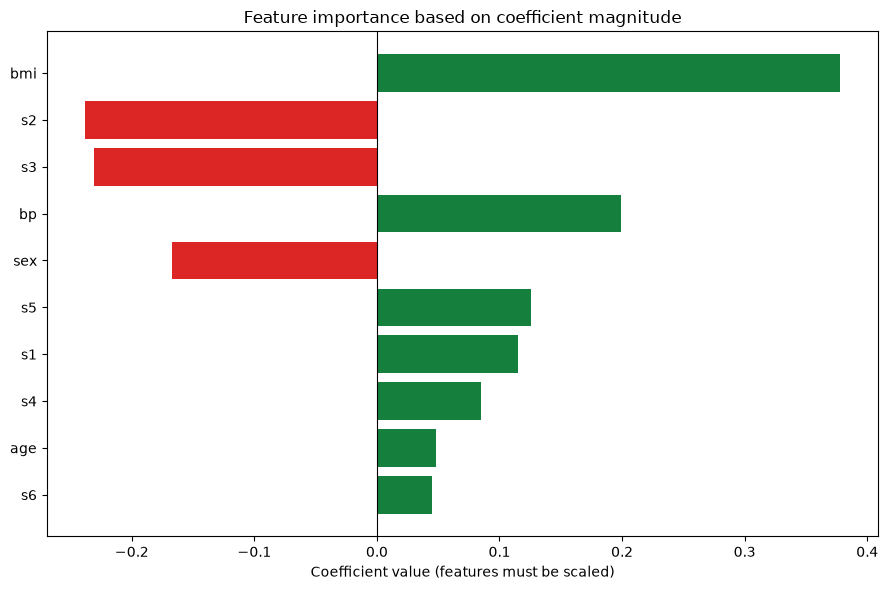

In [6]:
ax = best_demo_model.plot_feature_importance(diabetes.feature_names)
plt.tight_layout()
plt.show()

## Step 7 — How to use the class in later tasks

```python
model = RidgeRegression(
    method='mini', lr=0.01, l=0.01, bs=50,
    initialization='xavier',
    use_momentum=True, momentum=0.9
)
model.fit(X_train, y_train)
predictions = model.predict(X_test)
print(model.mse(y_test, predictions))
print(model.r2(y_test, predictions))
model.plot_feature_importance(feature_names)
```

Use `initialization='zeros'` to select zero initialization and `use_momentum=False` to disable momentum.